# Advanced List Concepts

Understanding how Python manages list objects in memory is crucial for avoiding subtle bugs. This section explores object identity, aliasing, and how lists behave when passed to functions.

In [ ]:
import sys
from pathlib import Path

# Find project root by looking for _config.yml
current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

# Add project root to path
sys.path.insert(0, str(project_root))

# Import shared teaching helpers and cell magics
from shared import thinkpython, diagram, jupyturtle, structshape
from shared.download import download


## Objects and Values

If we run these assignment statements:

In [82]:
a = 'banana'
b = 'banana'

We know that `a` and `b` both refer to a string, but we don't know whether they refer to the *same* string. 
There are two possible states, shown in the following figure.

In [83]:
from shared.diagram import Bbox, Binding, Frame, Stack, Value, adjust, diagram

s = 'banana'
bindings = [Binding(Value(name), Value(repr(s))) for name in 'ab']
frame1 = Frame(bindings, dy=-0.25)

binding1 = Binding(Value('a'), Value(repr(s)), dy=-0.11)
binding2 = Binding(Value('b'), draw_value=False, dy=0.11)
frame2 = Frame([binding1, binding2], dy=-0.25)

stack = Stack([frame1, frame2], dx=1.7, dy=0)


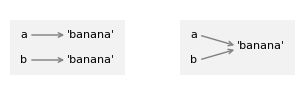

In [84]:
width, height, x, y = [2.85, 0.76, 0.17, 0.51]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

In the diagram on the left, `a` and `b` refer to two different objects that have the
same value. In the diagram on the right, they refer to the same object.
To check whether two variables refer to the same object, you can use the `is` operator.

In [85]:
a = 'banana'
b = 'banana'
a is b

True

In this example, Python only created one string object, and both `a`
and `b` refer to it.
But when you create two lists, you get two objects.

In [86]:
a = [1, 2, 3]
b = [1, 2, 3]
a is b

False

So the state diagram looks like this.

In [87]:
t = [1, 2, 3]
binding1 = Binding(Value('a'), Value(repr(t)))
binding2 = Binding(Value('b'), Value(repr(t)))
frame = Frame([binding1, binding2], dy=-0.25)

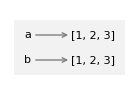

In [88]:
width, height, x, y = [1.16, 0.76, 0.21, 0.51]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y)
# adjust(x, y, bbox)

In this case we would say that the two lists are **equivalent**, because they have the same elements, but not **identical**, because they are not the same object. 
If two objects are identical, they are also equivalent, but if they are equivalent, they are not necessarily identical.

In [89]:
### EXERCISE: Objects and Values
x = [10, 20, 30]
y = x
z = [10, 20, 30]
# 1. Check if x and y refer to the same object using "is"
# 2. Check if x and z have the same value using "=="
# 3. Check if x and z refer to the same object using "is"
### Your code starts here:



### Your code ends here.

In [90]:
# Solution
x = [10, 20, 30]
y = x
z = [10, 20, 30]

same_object_xy = x is y
same_value_xz = x == z
same_object_xz = x is z

print(f"x is y: {same_object_xy}")  # True - same object (alias)
print(f"x == z: {same_value_xz}")   # True - same value (equivalent)
print(f"x is z: {same_object_xz}")  # False - different objects

x is y: True
x == z: True
x is z: False


## Aliasing

If `a` refers to an object and you assign `b = a`, then both variables refer to the same object.

In [91]:
a = [1, 2, 3]
b = a
b is a

True

So the state diagram looks like this.

In [92]:
t = [1, 2, 3]
binding1 = Binding(Value('a'), Value(repr(t)), dy=-0.11)
binding2 = Binding(Value('b'), draw_value=False, dy=0.11)
frame = Frame([binding1, binding2], dy=-0.25)

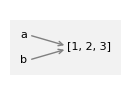

In [93]:
width, height, x, y = [1.11, 0.81, 0.17, 0.56]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y)
# adjust(x, y, bbox)

The association of a variable with an object is called a **reference**.
In this example, there are two references to the same object.

An object with more than one reference has more than one name, so we say the object is **aliased**.
If the aliased object is mutable, changes made with one name affect the other.
In this example, if we change the object `b` refers to, we are also changing the object `a` refers to.

In [94]:
b[0] = 5
a

[5, 2, 3]

So we would say that `a` "sees" this change.
Although this behavior can be useful, it is error-prone.
In general, it is safer to avoid aliasing when you are working with mutable objects.

For immutable objects like strings, aliasing is not as much of a problem.
In this example:

In [95]:
c = 'banana'
d = 'banana'

It almost never makes a difference whether `a` and `b` refer to the same
string or not.

In [96]:
### EXERCISE: Aliasing
a = [1, 2, 3]
# 1. Create an alias b that points to the same list as a
# 2. Modify the list through b by changing the first element to 99
# 3. Create a true copy c using slicing
# 4. Modify c and observe that a remains unchanged
### Your code starts here:



### Your code ends here.

In [97]:
# Solution
a = [1, 2, 3]
b = a  # alias
b[0] = 99

print(f"a after aliasing: {a}")
print(f"b: {b}")
print(f"Same object? {a is b}")

c = a[:]  # true copy
c[1] = 777

print(f"\na after copying: {a}")
print(f"c: {c}")
print(f"Same object? {a is c}")

a after aliasing: [99, 2, 3]
b: [99, 2, 3]
Same object? True

a after copying: [99, 2, 3]
c: [99, 777, 3]
Same object? False


## List Arguments in Functions

When you pass a list to a function, the function gets a reference to the
list. If the function modifies the list, the caller sees the change. For
example, `pop_first` uses the list method `pop` to remove the first element from a list.

In [98]:
def pop_first(lst):
    return lst.pop(0)

We can use it like this.

In [99]:
letters = ['a', 'b', 'c']
pop_first(letters)

'a'

The return value is the first element, which has been removed from the list -- as we can see by displaying the modified list.

In [100]:
letters

['b', 'c']

In this example, the parameter `lst` and the variable `letters` are aliases for the same object, so the state diagram looks like this:

In [101]:
from shared.diagram import make_list, Binding, Value

lst = make_list('abc', dy=-0.3, offsetx=0.1)
binding1 = Binding(Value('letters'), draw_value=False)
frame1 = Frame([binding1], name='__main__', loc='left')

binding2 = Binding(Value('lst'), draw_value=False, dx=0.61, dy=0.35)
frame2 = Frame([binding2], name='pop_first', loc='left', offsetx=0.08)

stack = Stack([frame1, frame2], dx=-0.3, dy=-0.5)

[np.float64(2.05), np.float64(1.22), np.float64(1.06), np.float64(0.85)]

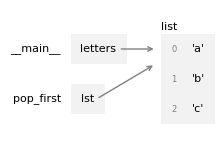

In [102]:
width, height, x, y = [2.04, 1.24, 1.06, 0.85]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = lst.draw(ax, x+0.5, y)
bbox = Bbox.union([bbox1, bbox2])
adjust(x, y, bbox)

Passing a reference to an object as an argument to a function creates a form of aliasing.
If the function modifies the object, those changes persist after the function is done.

In [ ]:
### EXERCISE: List Arguments in Functions
def add_item(lst, item):
    """Add item to list and return the list"""
    lst.append(item)
    return lst

# 1. Create a list with [1, 2, 3], call it original
# 2. Call add_item with your list and the value 4, 
#    save the result in a variable called updated
# 3. Print the original list to see if it changed after calling the function
# 4. check if original and updated refer to the same object using "is"
### Your code starts here:



### Your code ends here.

In [111]:
# Solution
def add_item(lst, item):
    """Add item to list and return the list"""
    lst.append(item)
    return lst

original = [1, 2, 3]
print(f"Original list: {original}")

updated = add_item(original, 4)
print(f"Returned list: {updated}")
print(f"Original list after function call: {original}")
print(f"Same object? {updated is original}")

Original list: [1, 2, 3]
Returned list: [1, 2, 3, 4]
Original list after function call: [1, 2, 3, 4]
Same object? True


## `any()` and `all()`

`any(iterable)` returns `True` if at least one element is truthy.
`all(iterable)` returns `True` if every element is truthy (also `True` for an empty iterable).

Passing a **list comprehension** is the clearest way to express these checks when working with lists.

In [ ]:
scores = [72, 88, 95, 61, 79]

# all() — True only if every element satisfies the condition
print(all([score >= 60 for score in scores]))   # True  — everyone passed
print(all([score >= 90 for score in scores]))   # False — not everyone got an A

In [ ]:
words = ['hello', 'world', 'programming', 'python']

# any() — True if at least one element satisfies the condition
print(any([len(word) > 10 for word in words]))          # True  — 'programming'
print(any([word.startswith('z') for word in words]))    # False

Common patterns in data work:

- `all([score >= 60 for score in scores])` — check whether every student passed
- `any([pd.isna(v) for v in row])` — check for any missing value in a row
- `all([col in df.columns for col in required])` — validate required columns exist

In Chapter 12 (Iterators & Generators) you will see that the list brackets can be dropped — `any(x > 0 for x in values)` — which avoids building the intermediate list entirely and lets the function short-circuit as soon as the result is determined.

In [ ]:
### EXERCISE: any() and all()
numbers = [2, 4, 6, 8, 9]
words = ['python', 'java', 'javascript', 'go']

# 1. Use all() with a list comprehension to check if all numbers are even.
# 2. Use any() with a list comprehension to check if any word starts with 'j'.
# 3. Use any() with a list comprehension to check if any number is greater than 10.
### Your code starts here:



### Your code ends here.

In [ ]:
# Solution
numbers = [2, 4, 6, 8, 9]
words = ['python', 'java', 'javascript', 'go']

print(all([num % 2 == 0 for num in numbers]))        # False — 9 is odd
print(any([word.startswith('j') for word in words])) # True
print(any([num > 10 for num in numbers]))             # False